<a href="https://colab.research.google.com/github/zwimpee/cursivetransformer/blob/main/cursivetransformer_mech_interp_part_3_stroke_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing Attention on Stroke Tokens

# Setup

In [1]:
!pip install transformer_lens
!pip install gradio
!pip install wandb
!pip install einops
!pip install matplotlib
!pip install datasets

# Clone the cursivetransformer repository and install its requirements
!rm -rf cursivetransformer && git clone https://github.com/zwimpee/cursivetransformer.git
!pip install -r cursivetransformer/requirements.txt

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.6/175.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.8/313.8 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7

In [2]:
import sys
sys.path.append('/content/cursivetransformer')
from cursivetransformer.model import get_all_args, get_checkpoint, get_latest_checkpoint_artifact
from cursivetransformer.data import create_datasets, offsets_to_strokes, strokes_to_offsets
from cursivetransformer.sample import generate, generate_n_words, plot_strokes
from cursivetransformer.mech_interp import (
    HookedCursiveTransformer,
    HookedCursiveTransformerConfig,
    convert_cursivetransformer_model_config,
    visualize_attention,
    generate_repeated_stroke_tokens,
    generate_random_ascii_context,
    run_and_cache_model_repeated_tokens,
    compute_induction_scores,
    plot_induction_scores,
    plot_head_attention_pattern,
    create_induction_summary,
    ablate_heads,
    get_induction_positions,
    compute_loss_on_induction_positions
)

import pandas as pd
import os

import copy
import types
from typing import List, Callable, Dict, Optional, Union, Tuple
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import einops
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import circuitsvis as cv
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from jaxtyping import Float, Int


import transformer_lens.utils as utils
from transformer_lens.hook_points import HookPoint
from transformer_lens import ActivationCache

torch.set_grad_enabled(False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import wandb
wandb.login()

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [23]:
args = get_all_args(False)
args.sample_only = True
args.max_seq_length = 1250
args.load_from_run_id = '7e9hz1og'
args.wandb_project = 'bigbank_2k'
args.wandb_entity = 'sam-greydanus'
args.dataset_name = 'bigbank'
args.wandb_run_name = 'cursivetransformer_mech_interp_part_3_stroke_attention'
torch.manual_seed(args.seed)
torch.cuda.manual_seed_all(args.seed)
train_dataset, test_dataset = create_datasets(args)
args.vocab_size = train_dataset.get_vocab_size()
args.block_size = train_dataset.get_stroke_seq_length()
args.context_block_size = train_dataset.get_text_seq_length()
args.context_vocab_size = train_dataset.get_char_vocab_size()

# Load original model and plot generated strokes

In [30]:
# - [x] TODO: Load original model and plot generated strokes
model, optimizer, scheduler, step, best_loss = get_checkpoint(args, sample_only=True)
text = "Hello, Sam!"

Number of Transformer parameters: 379392
Model #params: 403840
Finding latest checkpoint for W&B run id 7e9hz1og
  model:best_checkpoint:v129
  model:best_checkpoint:v130
  model:best_checkpoint:v131
  model:best_checkpoint:v132
  model:best_checkpoint:v133
  model:best_checkpoint:v134
  model:best_checkpoint:v135
  model:best_checkpoint:v136
  model:best_checkpoint:v137
  model:best_checkpoint:v138
  model:best_checkpoint:v139
  model:best_checkpoint:v140
  model:best_checkpoint:v141
  model:best_checkpoint:v142
  model:best_checkpoint:v143
  model:best_checkpoint:v144
  model:best_checkpoint:v145
  model:best_checkpoint:v146
  model:best_checkpoint:v147
  model:best_checkpoint:v148
  wandb-history:run-7e9hz1og-history:v4
Selected:  model:best_checkpoint:v148


wandb:   1 of 1 files downloaded.  


In [31]:
offset_samp, point_samp = generate_n_words(model, test_dataset, text, n_words=2)

cuda:0


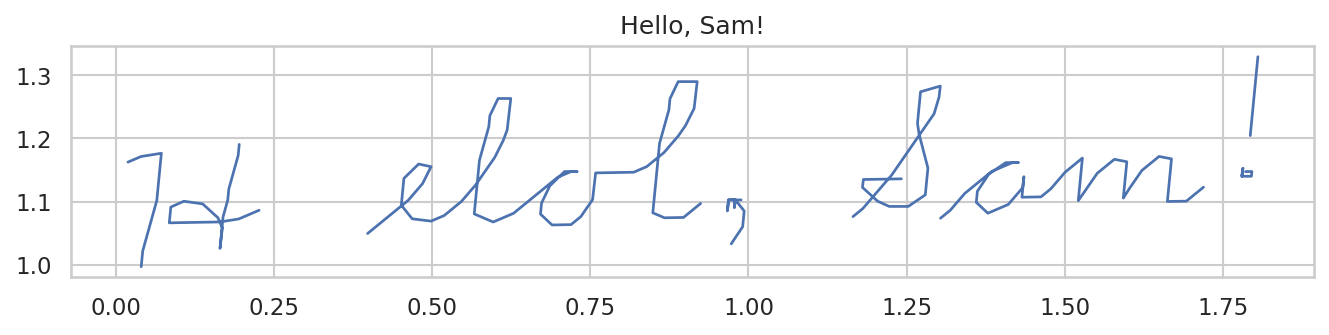

In [32]:
_ = plot_strokes(point_samp, text)

## Load model into HookedCursiveTransformer

In [ ]:
cfg = convert_cursivetransformer_model_config(args)
model = HookedCursiveTransformer.from_pretrained("cursivetransformer", cfg)